In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bitcoin-historical-data/btcusd_1-min_data.csv
/kaggle/input/drw-crypto-market-prediction/sample_submission.csv
/kaggle/input/drw-crypto-market-prediction/train.parquet
/kaggle/input/drw-crypto-market-prediction/test.parquet


In [2]:
!rm -rf /kaggle/working/crypto_market_prediction
!git clone https://github.com/CapstoneTeam23UMICH/crypto_market_prediction.git
!pip install -r /kaggle/working/crypto_market_prediction/requirements.txt

Cloning into 'crypto_market_prediction'...
remote: Enumerating objects: 3231, done.
remote: Counting objects: 100% (3100/3100), done.
remote: Compressing objects: 100% (2079/2079), done.
remote: Total 3231 (delta 598), reused 3032 (delta 567), pack-reused 131 (from 1)
Receiving objects: 100% (3231/3231), 28.43 MiB | 31.00 MiB/s, done.
Resolving deltas: 100% (649/649), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 78.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 52.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━

In [3]:
import sys
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import shap
from tqdm import tqdm
import warnings
import torch
import torch.nn as nn
import torch.optim as optim

import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
import gc

sys.path.append('/kaggle/working/crypto_market_prediction')

from src.github_push_file import push_parquet_to_github
from src.github_push_folder import push_folder_to_github

from src.get_refresh_metadata import (
    get_feature_drift_df,
    get_correlation_train_df,
    get_correlation_test_df,
    get_autocorrelation_train_df,
    get_adversarial_validation_df,
    get_mutual_information_train_df,
    get_correlation_stability_df,
    get_monthly_multivariate_granger,
    get_vif_train_df)

from src.common import (
    evaluate_regression, 
    evaluate_classification, 
    preprocess_classifier_sae)

from src.get_feature_set import get_feature_set
from src.get_cv_splits import get_folds_for_model
from src.augmented_rfe import augmented_rfe_timeseries_lightgbm

from src.model_registry import (
    model_registry_regression,
    model_registry_autoencoder)

from src.model_fit_predict import (
    fit_predict_tree, 
    fit_predict_mlp, 
    fit_predict_classifier_sae)

from src.run_cv import (
    to_tensor,
    run_cv,
    expand_grid,
    run_grid_search
)

df_drift = get_feature_drift_df()
df_corr_train = get_correlation_train_df()
df_autocorr = get_autocorrelation_train_df()
df_adv_val = get_adversarial_validation_df()
df_mutual_information = get_mutual_information_train_df()
df_corr_stability = get_correlation_stability_df()
df_granger = get_monthly_multivariate_granger()
df_vif = get_vif_train_df()

Loading existing df_feature_drift.parquet
Loading existing corr_long_train.parquet
Loading existing autocorr_long_train.parquet
Loading existing df_adversarial_validation.parquet
Loading existing df_mutual_information_train.parquet
Loading existing df_corr_stability.parquet
Loading existing df_vif.parquet


In [4]:
train_path = '/kaggle/input/drw-crypto-market-prediction/train.parquet'
test_path = '/kaggle/input/drw-crypto-market-prediction/test.parquet'

df_train = pd.read_parquet(train_path).astype('float32')
df_test = pd.read_parquet(test_path).astype('float32')

In [5]:
known_features = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
target = 'label'
anonymized_features = sorted(list(set(df_train.columns) - set(known_features) - set([target])), key=lambda x: int(x[1:]))

### Initial Feature Selection

In [35]:
selected_features = get_feature_set(anonymized_features, corr_thresh = 0.99, vif_tresh = 100, mi_tresh = 0.0)

Loading existing df_feature_drift.parquet
Loading existing corr_long_train.parquet
Loading existing autocorr_long_train.parquet
Loading existing df_adversarial_validation.parquet
Loading existing df_mutual_information_train.parquet
Loading existing df_vif.parquet
Returning Features Set of Size: 355


invalid value encountered in less


### Target Variable Analysis

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from scipy.stats import pearsonr, spearmanr, normaltest, jarque_bera
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [51]:
target = df_train['label']

print("=== TARGET VARIABLE ANALYSIS ===")
print(f"Count: {len(target):,}")
print(f"Mean: {target.mean():.6f}")
print(f"Median: {target.median():.6f}")
print(f"Std: {target.std():.6f}")
print(f"Min: {target.min():.6f}")
print(f"Max: {target.max():.6f}")
print(f"Skewness: {target.skew():.6f}")
print(f"Kurtosis: {target.kurtosis():.6f}")

try:
    stat, p_value = normaltest(target.dropna())
    print(f"Normality test p-value: {p_value:.6f}")
    if p_value < 0.05:
        print("Target is NOT normally distributed")
    else:
        print("Target appears normally distributed")
except:
    print("Could not perform normality test")

# Outliers using IQR
Q1, Q3 = target.quantile(0.25), target.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = target[(target < lower_bound) | (target > upper_bound)]
print(f"Outliers (IQR method): {len(outliers)} ({len(outliers)/len(target)*100:.2f}%)")

=== TARGET VARIABLE ANALYSIS ===
Count: 525,886
Mean: 0.036126
Median: 0.016261
Std: 1.009776
Min: -24.416615
Max: 20.740271
Skewness: -0.113487
Kurtosis: 15.991710
Normality test p-value: 0.000000
Target is NOT normally distributed
Outliers (IQR method): 40161 (7.64%)


use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
The figure layout has changed to tight


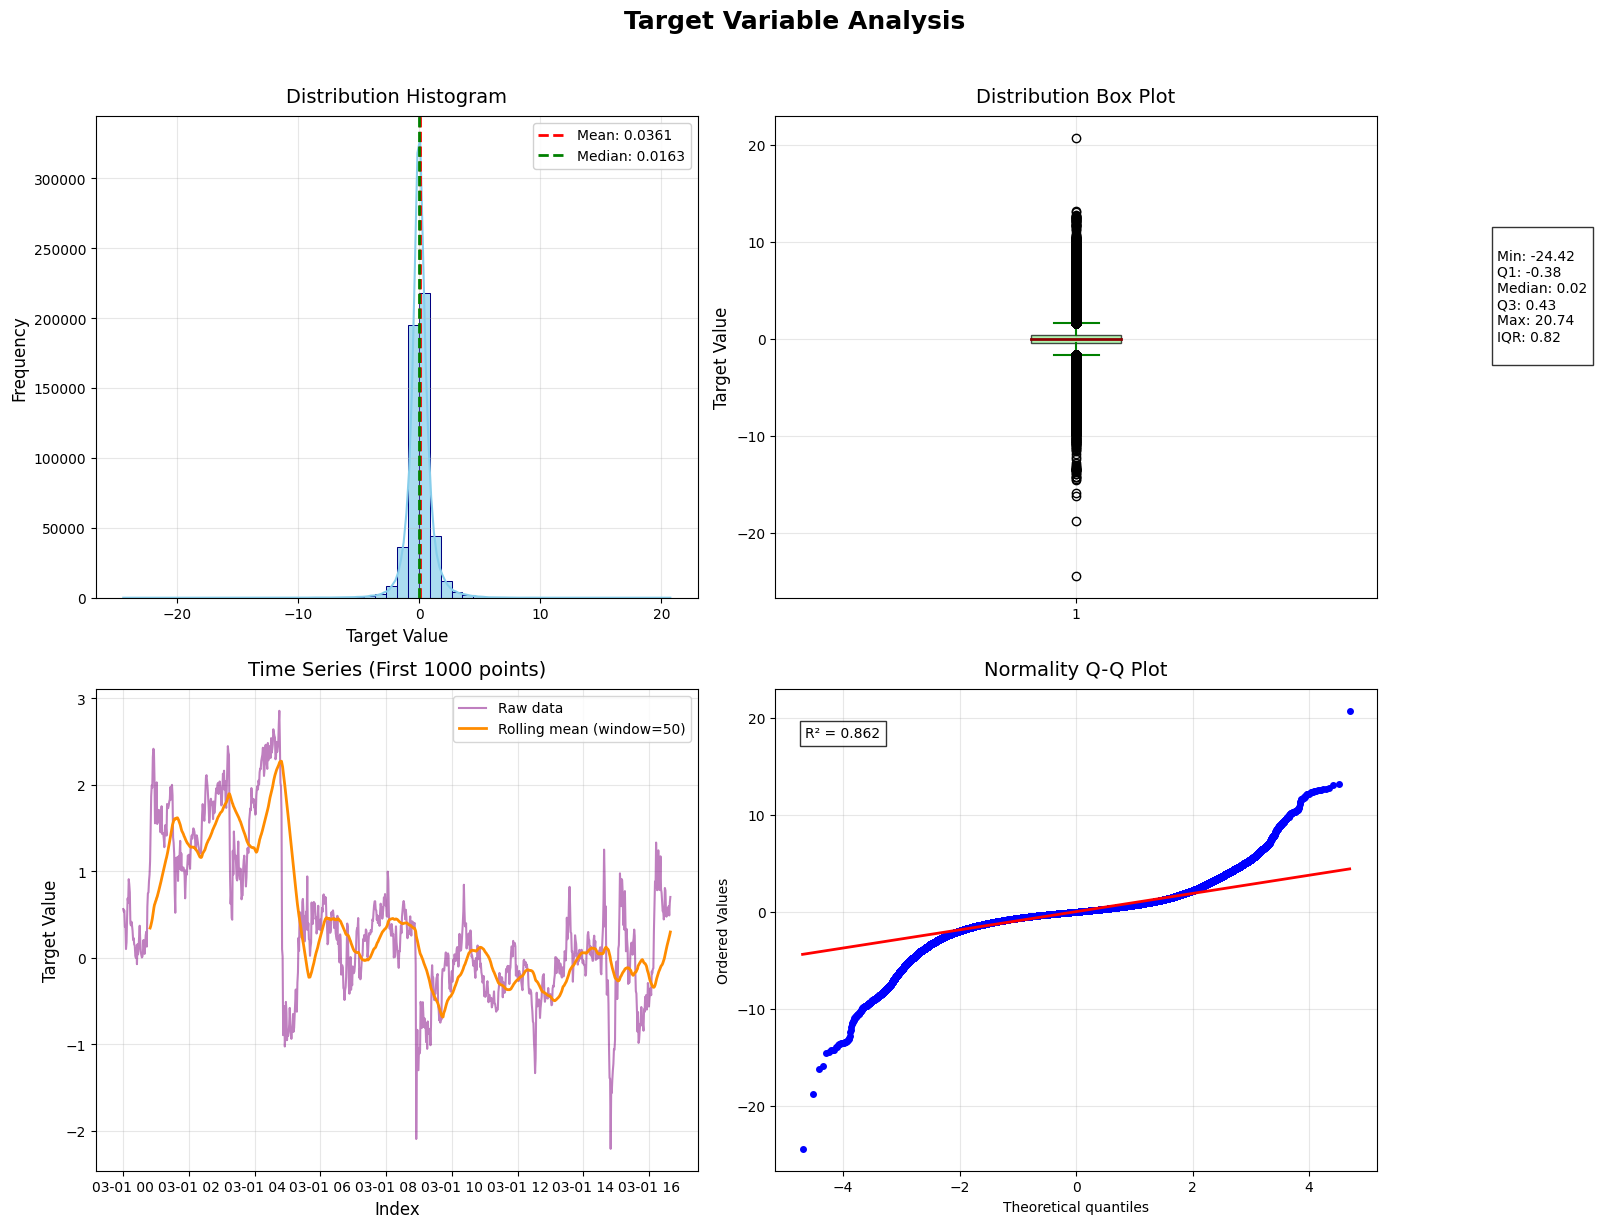

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
fig.suptitle('Target Variable Analysis', fontsize=18, y=1.02, fontweight='bold')

sns.histplot(target, bins=50, kde=True, ax=axes[0,0], color='skyblue', edgecolor='navy', alpha=0.7)
axes[0,0].axvline(target.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {target.mean():.4f}')
axes[0,0].axvline(target.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {target.median():.4f}')
axes[0,0].set_title('Distribution Histogram', fontsize=14, pad=10)
axes[0,0].set_xlabel('Target Value', fontsize=12)
axes[0,0].set_ylabel('Frequency', fontsize=12)
axes[0,0].legend(fontsize=10, framealpha=0.9)
axes[0,0].grid(True, alpha=0.3)
box = axes[0,1].boxplot(target, patch_artist=True, 
                        boxprops=dict(facecolor='lightgreen', alpha=0.7),
                        whiskerprops=dict(color='green', linewidth=1.5),
                        capprops=dict(color='green', linewidth=1.5),
                        medianprops=dict(color='darkred', linewidth=2))

# summary statistics
stats_text = f"""
Min: {np.min(target):.2f}
Q1: {np.percentile(target, 25):.2f}
Median: {np.median(target):.2f}
Q3: {np.percentile(target, 75):.2f}
Max: {np.max(target):.2f}
IQR: {np.percentile(target, 75) - np.percentile(target, 25):.2f}
"""
axes[0,1].text(1.2, 0.5, stats_text, transform=axes[0,1].transAxes, 
              bbox=dict(facecolor='white', alpha=0.8), fontsize=10)
axes[0,1].set_title('Distribution Box Plot', fontsize=14, pad=10)
axes[0,1].set_ylabel('Target Value', fontsize=12)
axes[0,1].grid(True, alpha=0.3)

# Time series with rolling average
sample_size = min(1000, len(target))
rolling_window = sample_size // 20  # 5% of sample size

axes[1,0].plot(target[:sample_size], alpha=0.5, color='purple', label='Raw data')
axes[1,0].plot(pd.Series(target[:sample_size]).rolling(rolling_window).mean(), 
              color='darkorange', linewidth=2, label=f'Rolling mean (window={rolling_window})')
axes[1,0].set_title(f'Time Series (First {sample_size} points)', fontsize=14, pad=10)
axes[1,0].set_xlabel('Index', fontsize=12)
axes[1,0].set_ylabel('Target Value', fontsize=12)
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3)

# Q-Q plot with R² value
stats.probplot(target, dist="norm", plot=axes[1,1])
axes[1,1].lines[0].set_markerfacecolor('blue')
axes[1,1].lines[0].set_markersize(4.0)
axes[1,1].lines[1].set_color('red')
axes[1,1].lines[1].set_linewidth(2.0)

# Calculate R² for the Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(target, dist="norm")
axes[1,1].text(0.05, 0.9, f'R² = {r**2:.3f}', transform=axes[1,1].transAxes,
              bbox=dict(facecolor='white', alpha=0.8))
axes[1,1].set_title('Normality Q-Q Plot', fontsize=14, pad=10)
axes[1,1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The target variable appears to be a modified version of the Bitcoin price. As seen in Figure below, it follows the same general trend and turning points but at a lower scale and with reduced volatility. This suggests it was smoothed, aggregated, or shifted in time to reduce noise while preserving the main directional patterns.

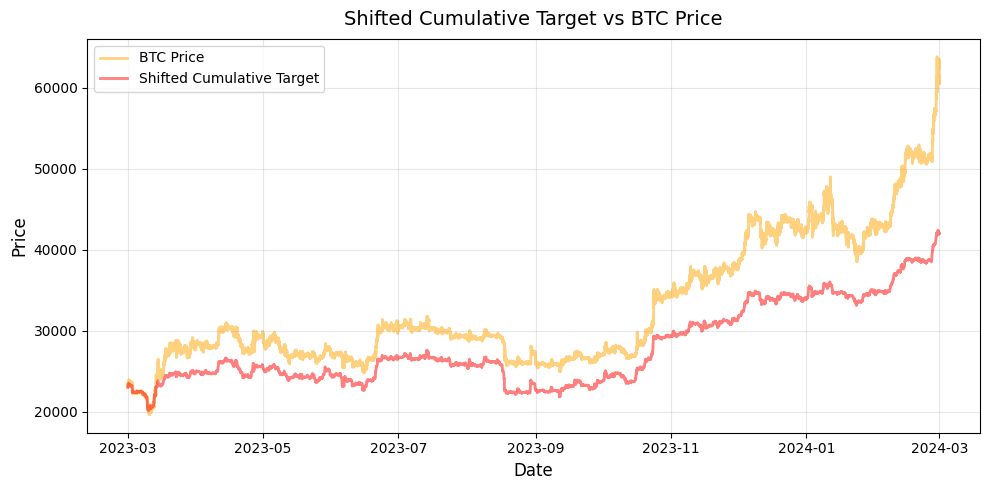

In [52]:
df_btc = pd.read_csv('/kaggle/input/bitcoin-historical-data/btcusd_1-min_data.csv')
df_btc['Timestamp'] = pd.to_datetime(df_btc['Timestamp'], unit='s')
df_btc.set_index('Timestamp', inplace=True)
df_price = pd.concat([df_train['label'].cumsum() +23000, df_btc['Close']], axis=1, join='inner')

plt.figure(figsize=(10, 5))

plt.plot(df_price.index, 
         df_price['Close'], 
         alpha=0.5, color='orange', linewidth=2, label='BTC Price')
plt.plot(df_price.index, 
         df_price['label'], 
         alpha=0.5, color='red', linewidth=2, label='Shifted Cumulative Target')

plt.title('Shifted Cumulative Target vs BTC Price', fontsize=14, pad=10)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Missing Value Check

In [38]:
print("=== MISSING VALUES ANALYSIS ===")

train_missing = df_train.isnull().sum()
train_missing_pct = (train_missing / len(df_train)) * 100
train_missing_df = pd.DataFrame({
    'Missing_Count': train_missing,
    'Missing_Percent': train_missing_pct
})
train_missing_df = train_missing_df[train_missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"Training data:")
print(f"Columns with missing values: {len(train_missing_df)}")
if len(train_missing_df) > 0:
    print("Top 10 columns with missing values:")
    print(train_missing_df.head(10))
else:
    print("No missing values in training data!")

test_missing = df_test.isnull().sum()
test_missing_pct = (test_missing / len(df_test)) * 100
test_missing_df = pd.DataFrame({
    'Missing_Count': test_missing,
    'Missing_Percent': test_missing_pct
})
test_missing_df = test_missing_df[test_missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print(f"\nTest data:")
print(f"Columns with missing values: {len(test_missing_df)}")
if len(test_missing_df) > 0:
    print("Top 10 columns with missing values:")
    print(test_missing_df.head(10))
else:
    print("No missing values in test data!")

=== MISSING VALUES ANALYSIS ===
Training data:
Columns with missing values: 27
Top 10 columns with missing values:
      Missing_Count  Missing_Percent
X94               1          0.00019
X426              1          0.00019
X778              1          0.00019
X767              1          0.00019
X758              1          0.00019
X738              1          0.00019
X710              1          0.00019
X613              1          0.00019
X605              1          0.00019
X585              1          0.00019

Test data:
Columns with missing values: 0
No missing values in test data!


## Initial Feature Selection

With more than 700 initial features, our first objective was to reduce the set to around 200, creating a manageable base for more computationally intensive methods. From there, we applied advanced techniques such as causality-based selection, supervised autoencoders, and iterative feature elimination to narrow the set further to roughly 50 features. This staged process maintained efficiency while preserving the ability to capture complex relationships in the final selection.

### Pariwise Correlation Filter

One of the most cost-effective and straightforward feature filtering approaches we employed was pairwise correlation analysis. By calculating the absolute Pearson correlation between all feature pairs and removing one feature from any pair with a correlation greater than 0.99, we were able to quickly reduce redundancy without complex modeling. This method is computationally inexpensive, easy to implement, and effective at eliminating near-duplicate features that contribute little new information, thereby improving model efficiency while preserving overall predictive capacity.

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
invalid value encountered in less


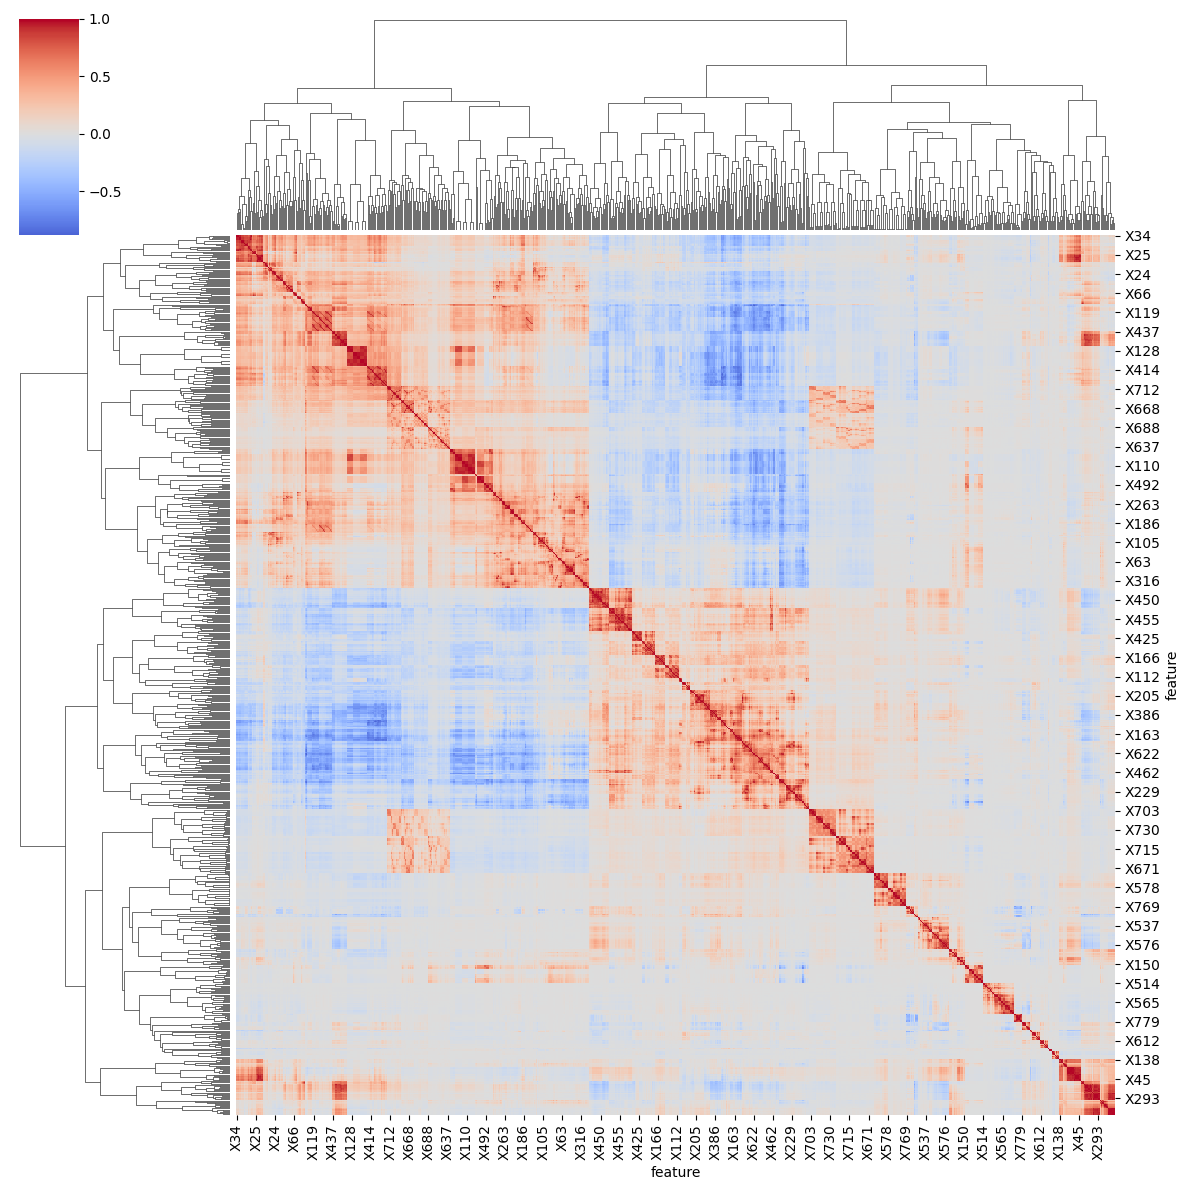

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

df_corr_train['corr'] = pd.to_numeric(df_corr_train['corr'], errors='coerce')
features = sorted(set(df_corr_train['x']).union(set(df_corr_train['y'])))
idx = pd.Index(features, name='feature')
C = pd.DataFrame(np.eye(len(idx)), index=idx, columns=idx)  
for _, row in df_corr_train.iterrows():
    a, b, r = row['x'], row['y'], row['corr']
    if pd.notna(r) and a in C.index and b in C.columns:
        C.loc[a, b] = r
        C.loc[b, a] = r

sns. clustermap(
    C,
    cmap='coolwarm', center=0,
    figsize=(12, 12),
    row_cluster=True, col_cluster=True,
    dendrogram_ratio=0.2,
    cbar_pos=(0.02, 0.8, 0.05, 0.18)
)

plt.show()

In [47]:
df_corr_train[df_corr_train['corr'] > 0.99].sort_values(
    by = ['corr'], ascending = False).head(20)

,x,y,corr
71113,X134,X92,1.0
80485,X104,X146,1.0
61741,X122,X80,1.0
61783,X164,X80,1.0
66427,X128,X86,1.0
66469,X170,X86,1.0
264020,X339,X381,1.0
71155,X176,X92,1.0
75799,X140,X98,1.0
75841,X182,X98,1.0


### Multicollinearity Filter

To address multicollinearity, we applied iterative variance inflation factor (VIF) filtering, prioritizing interpretability and model stability. While we recognized that aggressive VIF thresholds can risk removing variables involved in nonlinear relationships, we set a deliberately high cutoff (VIF > 100) to minimize this risk. Even under this conservative criterion, the procedure eliminated more than 200 features, substantially reducing redundancy while preserving most potentially relevant signals.

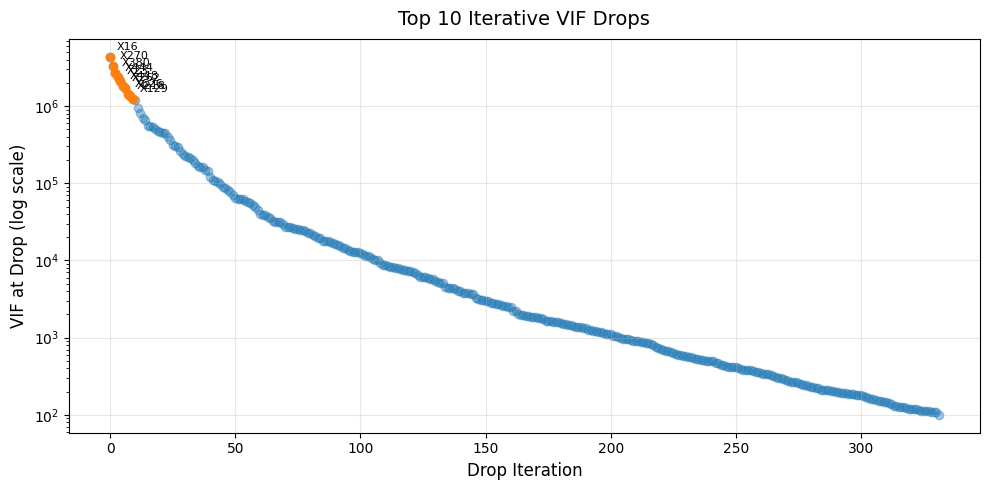

In [33]:
df_vif['drop_iter'] = pd.to_numeric(df_vif['drop_iter'], errors='coerce')
df_vif['drop_vif']  = pd.to_numeric(df_vif['drop_vif'],  errors='coerce')

dropped = df_vif[df_vif['feature_drop']].dropna(subset=['drop_iter','drop_vif']).copy()
kept    = df_vif[~df_vif['feature_drop']].copy()
annotate_k = 10
biggest = dropped.nlargest(annotate_k, 'drop_vif')
plt.figure(figsize=(10, 5))
plt.scatter(dropped['drop_iter'], dropped['drop_vif'], alpha=0.4)
plt.scatter(biggest['drop_iter'], biggest['drop_vif'])
for i, r in biggest.iterrows():
    plt.annotate(r['feature'], 
                 (r['drop_iter'], r['drop_vif']),
                 xytext=(5,5), 
                 textcoords='offset points', 
                 fontsize=8)
plt.yscale('log')
plt.title(f'Top {annotate_k} Iterative VIF Drops', fontsize=14, pad=10)
plt.xlabel('Drop Iteration', fontsize=12)
plt.ylabel('VIF at Drop (log scale)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Mutual Information Filter

Since conservative pairwise correlation and VIF filters reduced the features to 335, we required an additional filter with a low risk of information loss. We deliberately avoided PCA-like transformations to prevent potential nonlinear information loss. As a straightforward next step, we applied a conservative mutual information filter.

We also tested other initial filters, including correlation stability, adversarial selection, and model-based importance. However, these either risked losing too much information, introduced data leakage, or produced subpar results.

To aid experimentation, we implemented the get_feature_set() function that produces a set of features based on various initial filter configurations.

In [37]:
selected_features = get_feature_set(anonymized_features, 
                                    corr_thresh = 0.99, 
                                    vif_tresh = 100, 
                                    mi_tresh = 0.02)

Loading existing df_feature_drift.parquet
Loading existing corr_long_train.parquet
Loading existing autocorr_long_train.parquet
Loading existing df_adversarial_validation.parquet
Loading existing df_mutual_information_train.parquet
Loading existing df_vif.parquet
Returning Features Set of Size: 236


invalid value encountered in less


## Intermediate Feature Selection

### Causality Based Feature Selection

We applied multivariate Granger causality for feature selection, following the idea that stable causality leads to stable relationships (Li et al., 2024). However, performance on our test set was subpar, possibly due to the method’s linearity and fixed-lag assumptions. Future work could test nonlinear approaches such as Neural Granger or DynoTears, or apply Granger selection to denoised data from our autoencoder.

Reference
Li, X., Huang, X., Zhang, Y., & Zhou, Y. (2024). Enhancing financial market predictions: Causality-driven feature selection. In Proceedings of the 2024 International Conference on Advanced Data Mining and Applications (ADMA). arXiv. https://arxiv.org/abs/2408.01005

In [22]:
granger_features = get_feature_set(anonymized_features, corr_thresh = 0.99, vif_tresh = 100, mi_tresh = 0.04)
df_granger = get_monthly_multivariate_granger(df = df_train, 
                                              features = granger_features, 
                                              maxlags = 1, 
                                              alpha = 0.05, 
                                              github_token=github_token, 
                                              refresh_repo_file=True)

Multivariate Granger for 2024-02-29 00:00:00: 100%|██████████| 90/90 [00:29<00:00,  3.05it/s]


Saved /kaggle/working/df_monthly_multivariate_granger.parquet


Cloning into 'crypto_market_prediction'...
Switched to a new branch 'feature/df_monthly_multivariate_granger_1755116467'


[feature/df_monthly_multivariate_granger_1755116467 1ba597c] Add monthly multivariate granger dataframe
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite src/data/output/df_monthly_multivariate_granger.parquet (100%)
Pushed `df_monthly_multivariate_granger.parquet` to `crypto_market_prediction/feature/df_monthly_multivariate_granger_1755116467`


remote: Invalid username or token. Password authentication is not supported for Git operations.
fatal: Authentication failed for 'https://github.com/CapstoneTeam23UMICH/crypto_market_prediction.git/'


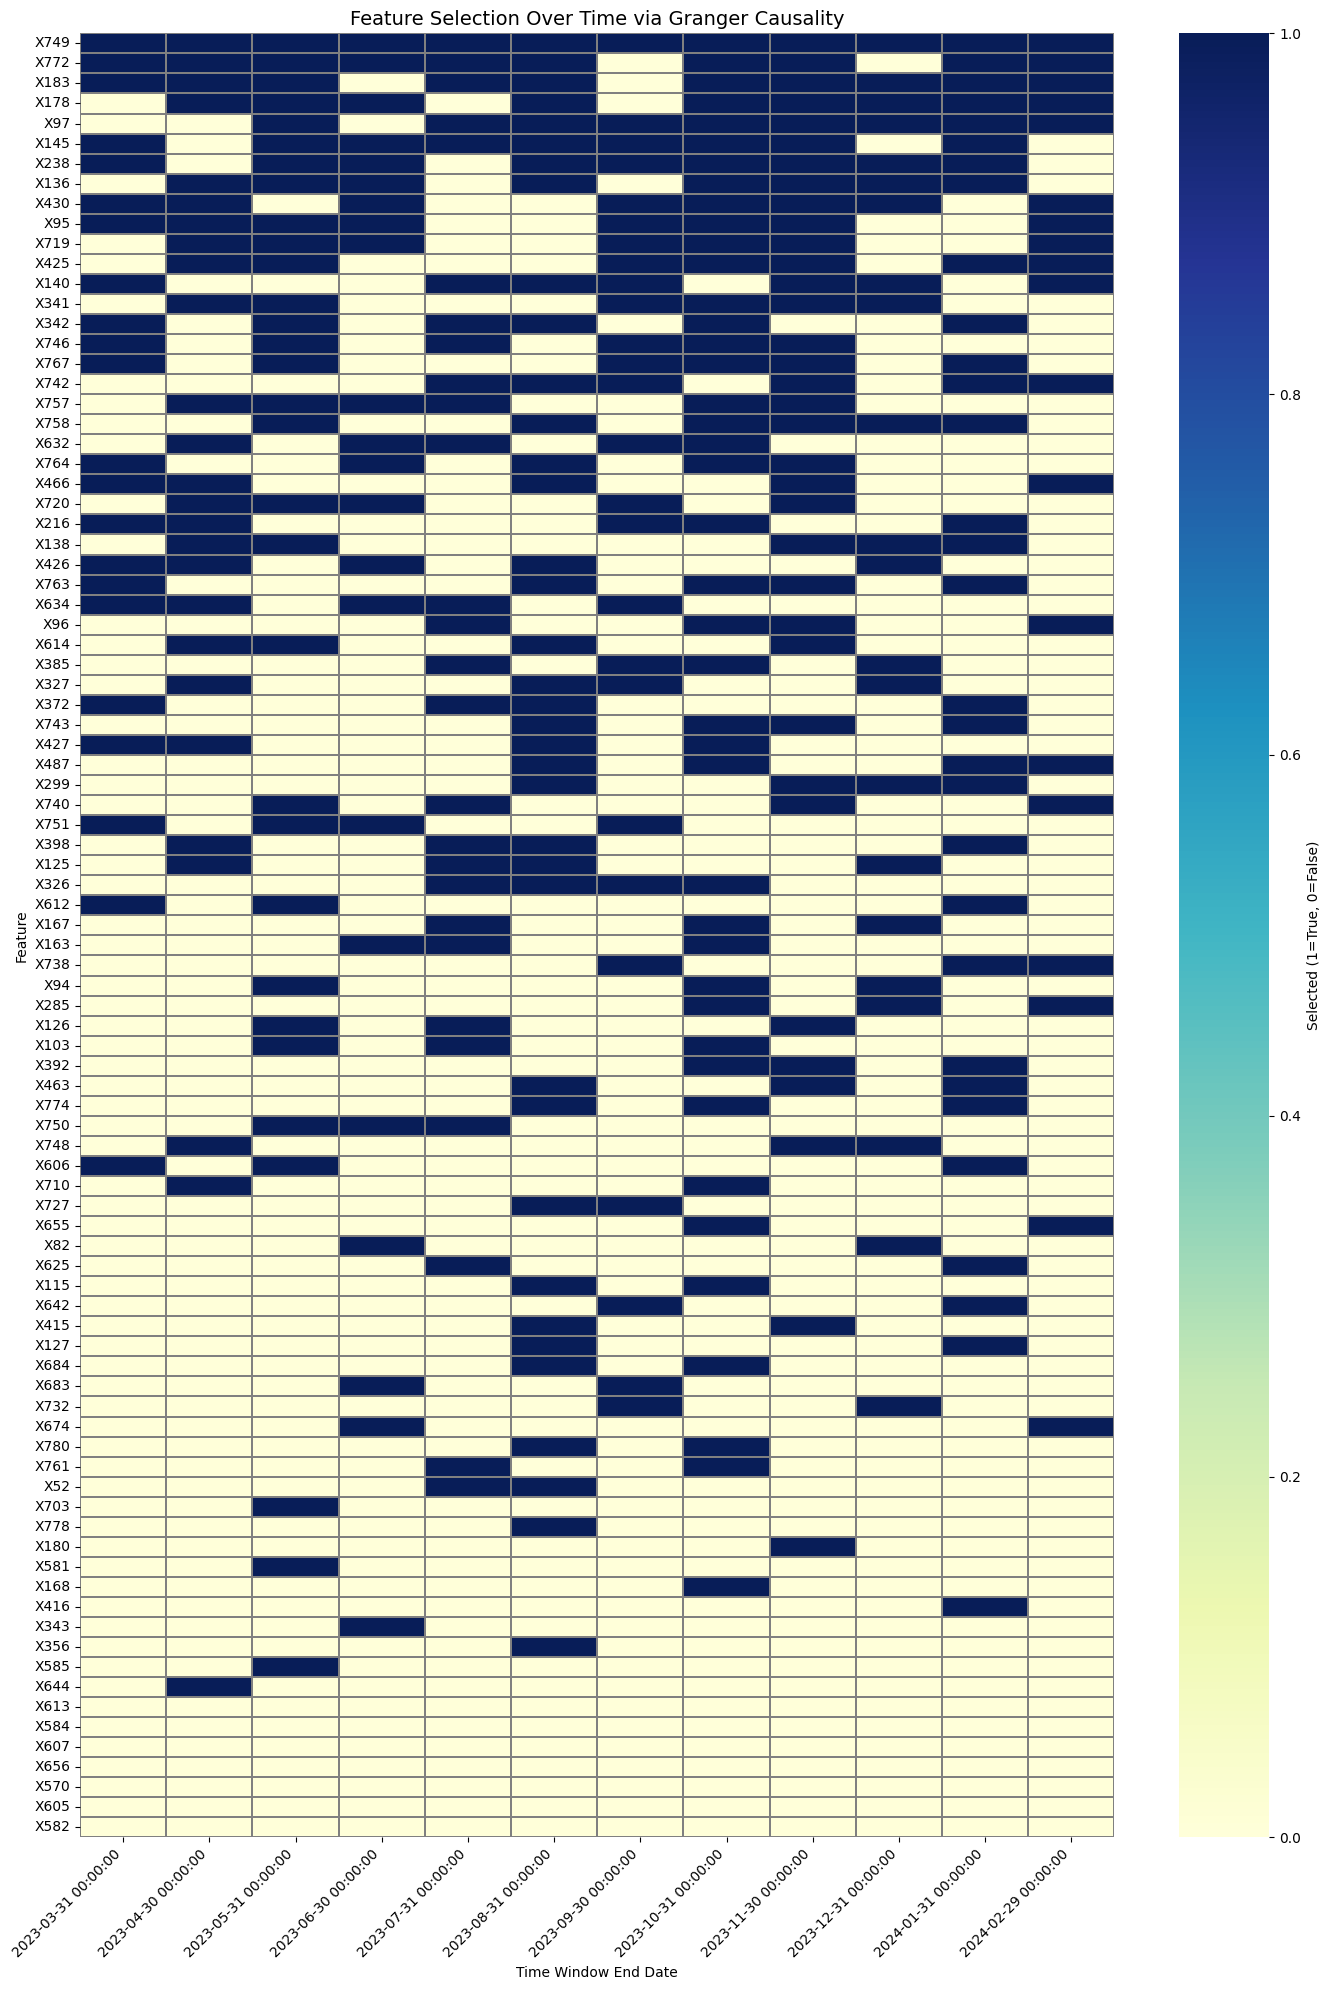

In [30]:
selection_numeric = df_granger.drop('feature', axis=1).astype(int)
selection_numeric = selection_numeric.loc[selection_numeric.sum(axis = 1).sort_values(ascending = False).index]

plt.figure(figsize=(14, min(0.4 * len(selection_numeric), 20))) 

sns.heatmap(
    selection_numeric,
    cmap='YlGnBu',
    cbar_kws={'label': 'Selected (1=True, 0=False)'},
    linewidths=0.1,
    linecolor='gray'
)

plt.title('Feature Selection Over Time via Granger Causality', fontsize=14)
plt.xlabel('Time Window End Date')
plt.ylabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Our feature selection approach evolved significatly over time. The final approach consists of initial filtering using pariwise correlation, vif and mutual information. Followed by a supervised autoencoder and augmented recursive feature elimination.

Some of the rejected approaches can be retested using existing saved metadata.

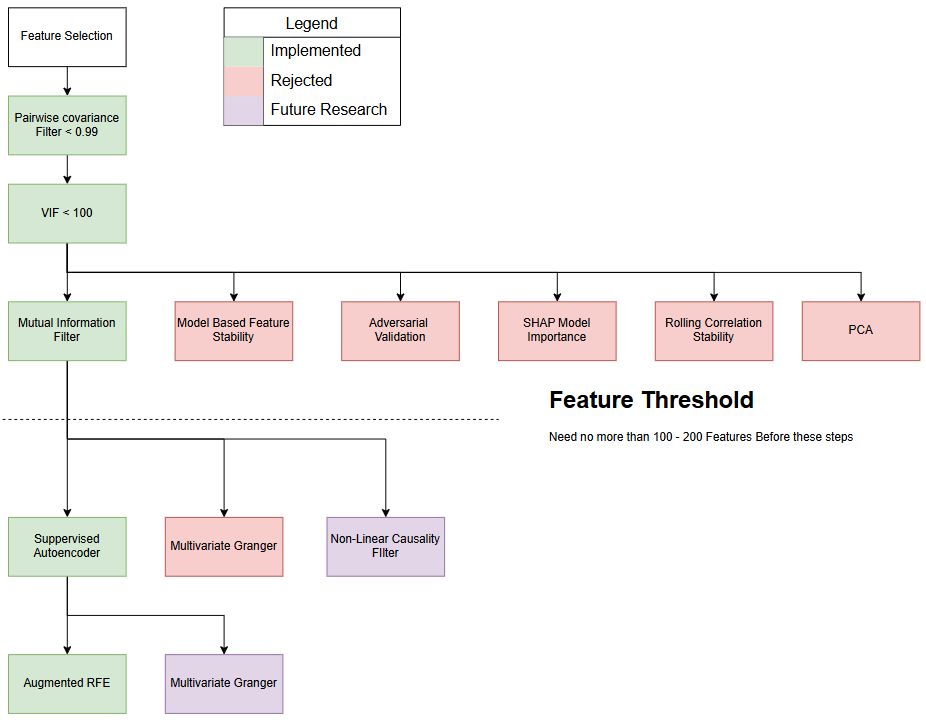